In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


C:\Users\KESHAV\AppData\Local\Temp\ipykernel_20444\3113421172.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


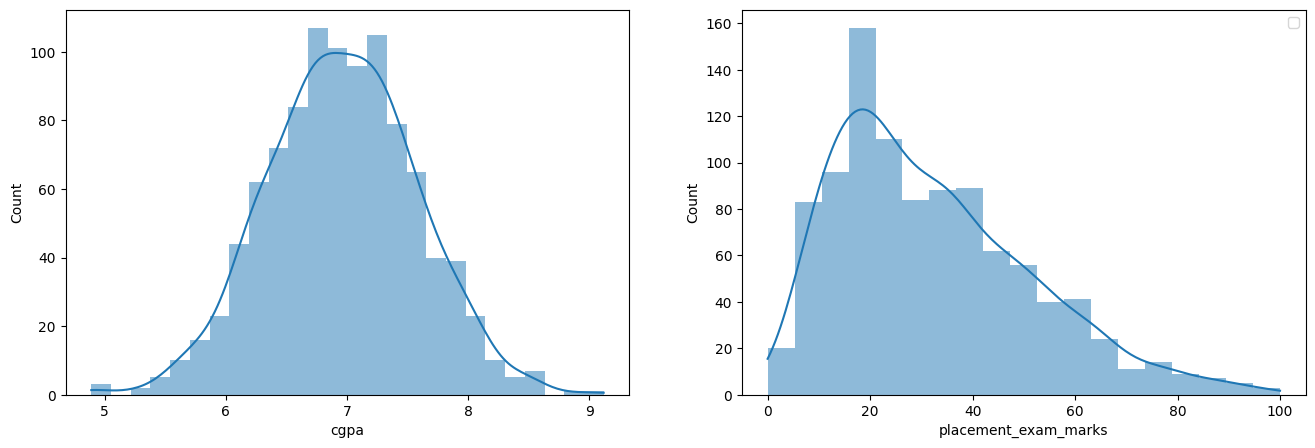

In [6]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True,edgecolor=None)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True,edgecolor=None)

plt.legend()

In [7]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='cgpa'>

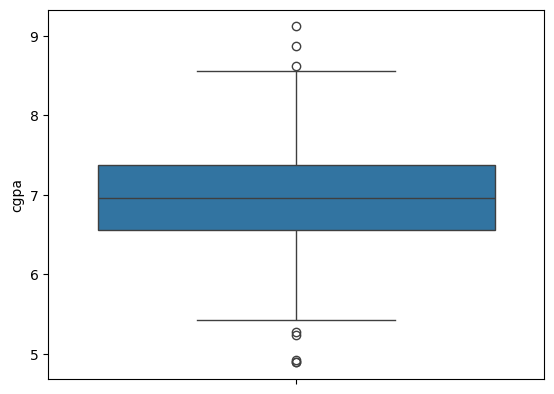

In [8]:
sns.boxplot(df['cgpa'])

<Axes: ylabel='placement_exam_marks'>

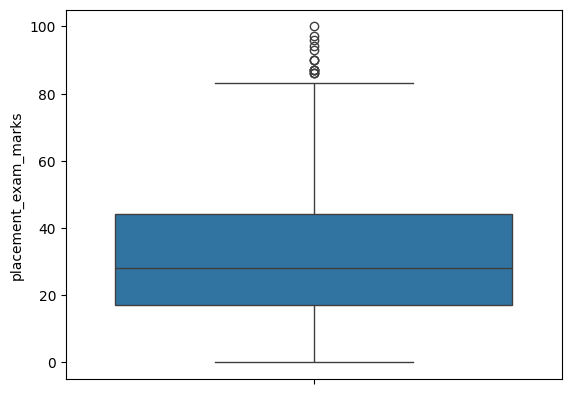

In [9]:
sns.boxplot(df['placement_exam_marks'])

In [10]:
# finding IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [12]:
iqr = percentile75 - percentile25

In [13]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 -1.5 * iqr

In [17]:
print(upper_limit)
print(lower_limit)

84.5
-23.5


In [19]:
print(df[df['placement_exam_marks'] > upper_limit])
print(df[df['placement_exam_marks'] < lower_limit])

     cgpa  placement_exam_marks  placed
9    7.75                  94.0       1
40   6.60                  86.0       1
61   7.51                  86.0       0
134  6.33                  93.0       0
162  7.80                  90.0       0
283  7.09                  87.0       0
290  8.38                  87.0       0
311  6.97                  87.0       1
324  6.64                  90.0       0
630  6.56                  96.0       1
685  6.05                  87.0       1
730  6.14                  90.0       1
771  7.31                  86.0       1
846  6.99                  97.0       0
917  5.95                 100.0       0
Empty DataFrame
Columns: [cgpa, placement_exam_marks, placed]
Index: []


## Trimming

In [20]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [21]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


<Axes: ylabel='placement_exam_marks'>

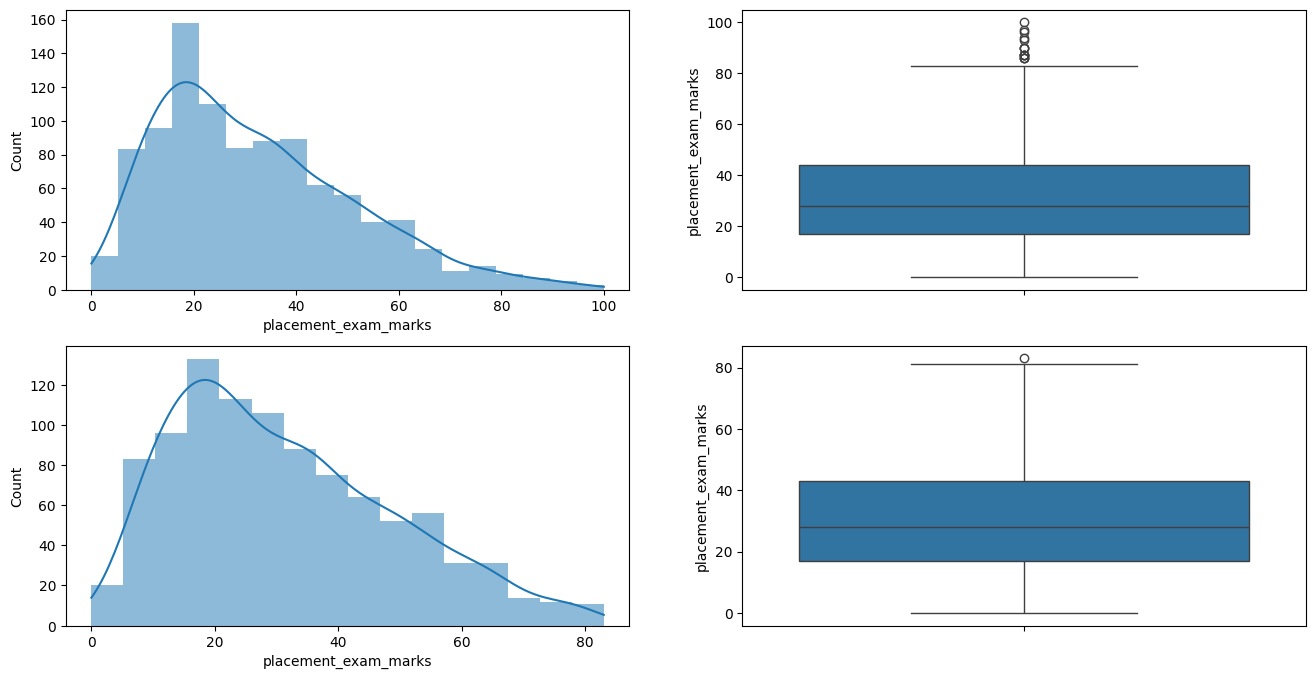

In [23]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True,edgecolor=None)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'],kde=True,edgecolor=None)

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

## Capping

In [32]:
new_df1 = df.copy()

In [33]:
new_df1 = np.where(df['placement_exam_marks'] > upper_limit, upper_limit, 
                  np.where(df['placement_exam_marks'] < lower_limit, lower_limit, 
                           df['placement_exam_marks']
                          )
                     )

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

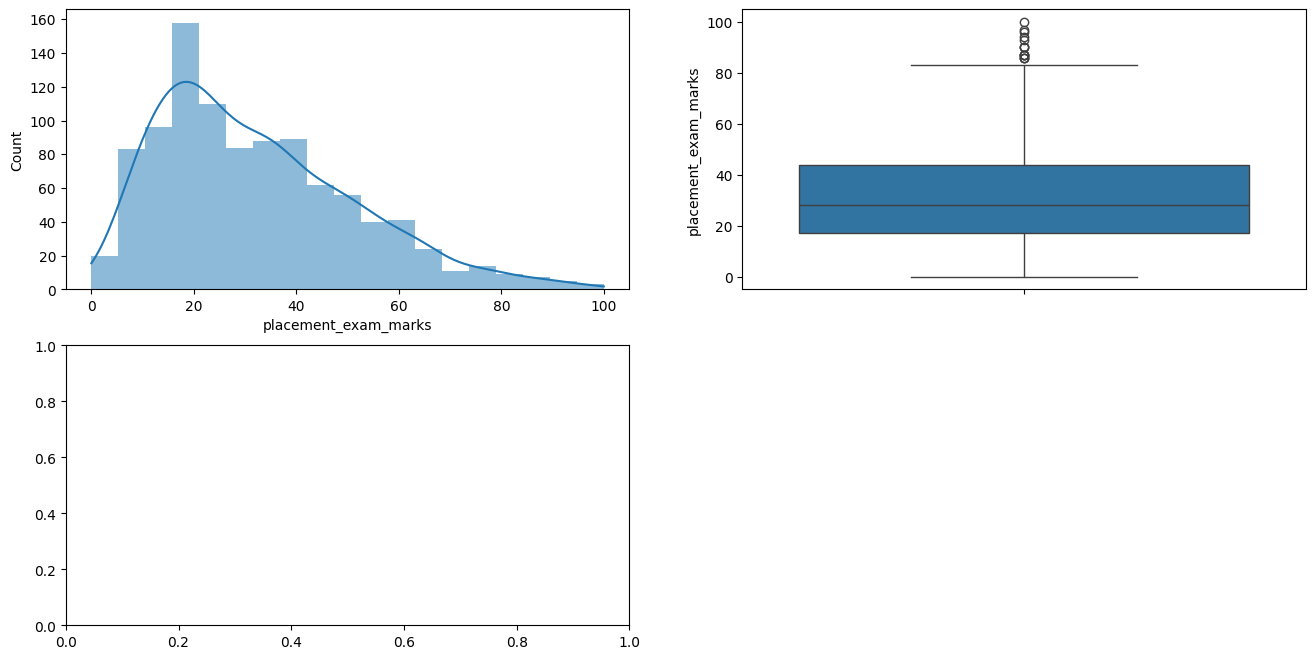

In [34]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True,edgecolor=None)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df1['placement_exam_marks'],kde=True,edgecolor=None)

plt.subplot(2,2,4)
sns.boxplot(new_df1['placement_exam_marks'])

plt.show()